# Part 2A-vii: Custom Metric — HuberMetric

**Objective:** Implement a streaming custom metric that computes Huber loss as a metric.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [2]:
# TF: Custom Streaming Metric
class HuberMetric(keras.metrics.Metric):
    """Custom streaming metric that computes Huber loss over batches.
    'Streaming' means it accumulates results across batches, not just one batch.
    """
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta
        self.total = self.add_variable(shape=(), initializer="zeros", name="total")
        self.count = self.add_variable(shape=(), initializer="zeros", name="count")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.squeeze(y_pred), tf.float32)
        error = y_true - y_pred
        is_small = tf.abs(error) <= self.delta
        small_error = 0.5 * tf.square(error)
        large_error = self.delta * (tf.abs(error) - 0.5 * self.delta)
        huber = tf.where(is_small, small_error, large_error)
        self.total.assign_add(tf.reduce_sum(huber))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config["delta"] = self.delta
        return config

# Also create a custom R² metric
class R2Score(keras.metrics.Metric):
    """Custom R² (coefficient of determination) metric."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.ss_res = self.add_variable(shape=(), initializer="zeros", name="ss_res")
        self.ss_tot_num = self.add_variable(shape=(), initializer="zeros", name="ss_tot_num")
        self.y_sum = self.add_variable(shape=(), initializer="zeros", name="y_sum")
        self.y_sq_sum = self.add_variable(shape=(), initializer="zeros", name="y_sq_sum")
        self.count = self.add_variable(shape=(), initializer="zeros", name="count")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.squeeze(y_true), tf.float32)
        y_pred = tf.cast(tf.squeeze(y_pred), tf.float32)
        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.y_sum.assign_add(tf.reduce_sum(y_true))
        self.y_sq_sum.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        y_mean = self.y_sum / self.count
        ss_tot = self.y_sq_sum - self.count * tf.square(y_mean)
        return 1.0 - self.ss_res / (ss_tot + 1e-8)

    def reset_state(self):
        self.ss_res.assign(0.0); self.y_sum.assign(0.0)
        self.y_sq_sum.assign(0.0); self.count.assign(0.0)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - huber: 0.4073 - loss: 1.2844 - mae: 0.7463 - r2: 0.0342 - val_huber: 0.2502 - val_loss: 0.6082 - val_mae: 0.5556 - val_r2: 0.5543
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber: 0.2085 - loss: 0.4943 - mae: 0.4981 - r2: 0.6283 - val_huber: 0.1962 - val_loss: 0.4594 - val_mae: 0.4735 - val_r2: 0.6633
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber: 0.1764 - loss: 0.4025 - mae: 0.4513 - r2: 0.6973 - val_huber: 0.1832 - val_loss: 0.4207 - val_mae: 0.4538 - val_r2: 0.6917
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber: 0.1678 - loss: 0.3797 - mae: 0.4384 - r2: 0.7145 - val_huber: 0.1760 - val_loss: 0.4011 - val_mae: 0.4442 - val_r2: 0.7061
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber: 0.1611 - loss: 0.3635 - mae: 0.4278 - r2: 0.7267 - val_huber: 0.1739 - val_loss: 0.3953 - val_mae: 0.4420 - val_r2: 0.7103
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - huber: 0.1572 - loss: 0.3

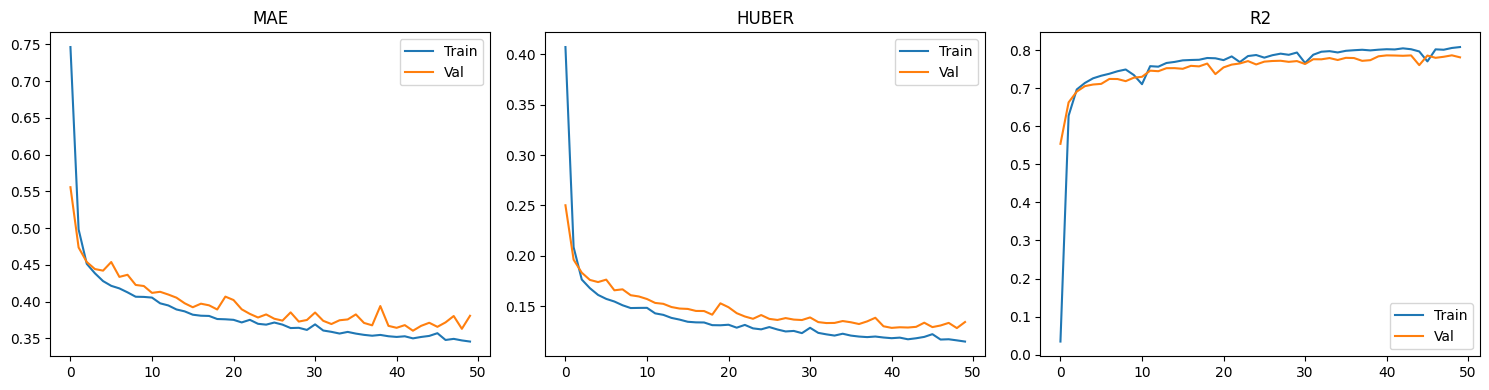


Test — MSE: 0.2895, MAE: 0.3736, Huber: 0.1293, R²: 0.7790


In [3]:
# Train with custom metrics
model = keras.Sequential([
    layers.Input(shape=(8,)), layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'), layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', HuberMetric(delta=1.0, name='huber'), R2Score(name='r2')]
)

history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

# Plot all metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['mae', 'huber', 'r2']):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Val')
    ax.set_title(metric.upper()); ax.legend()
plt.tight_layout(); plt.show()

# Final evaluation
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest — MSE: {results[0]:.4f}, MAE: {results[1]:.4f}, Huber: {results[2]:.4f}, R²: {results[3]:.4f}")

## Key Takeaways
- Custom metrics subclass `keras.metrics.Metric`
- Use `add_variable()` (Keras 3) for state variables that accumulate across batches
- Implement `update_state()`, `result()`, `reset_state()`
- `get_config()` makes the metric serializable (can save/load with model)
- Streaming metrics give correct results even with variable batch sizes